In [ ]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import fetch_california_housing

# Preprocessing & Model Selection
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [ ]:
# Load California Housing Dataset
housing = fetch_california_housing()

# Convert into pandas DataFrame for better readability
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Display first 5 rows
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
# Split Data into Training & Testing Sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

 ### **Linear Regression**

In [ ]:
# Linear Regression Model
lr = LinearRegression()

# Train the model
lr.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr.predict(X_test)

### **Decision Tree**

In [ ]:
# Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)

# Train model
dt.fit(X_train, y_train)

# Predictions
y_pred_dt = dt.predict(X_test)

### **Random Forest**

In [ ]:
# Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Train Model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

### **Support Vector Regressor**

In [ ]:
# Support Vector Regressor
svr = SVR()

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
svr.fit(X_train, y_train)

# Prediction
y_pred_svr = svr.predict(X_test)

### **Gradient Booster**

In [ ]:
# Gradient Boosting Regressor
gb = GradientBoostingRegressor(random_state=42)

# Train Model
gb.fit(X_train, y_train)

# Prediction
y_pred_gb = gb.predict(X_test)

### **Hyperparameter**

In [ ]:
# Hyperparameter Tuning using GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20]
}

# GridSearch with 3-fold cross-validation
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2'
)

# Train GridSearch
grid.fit(X_train, y_train)

# Get best model
best_rf = grid.best_estimator_

# Predict using tuned model
y_pred_best_rf = best_rf.predict(X_test)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'n_estimators': 200}


### **Model Evaluation**

In [ ]:
# Model Evaluation Function

def evaluate_model(name, y_test, y_pred):

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return [name, mae, mse, rmse, r2]



# Compare All Models
results = []

results.append(evaluate_model("Linear Regression", y_test, y_pred_lr))
results.append(evaluate_model("Decision Tree", y_test, y_pred_dt))
results.append(evaluate_model("Random Forest", y_test, y_pred_rf))
results.append(evaluate_model("SVR", y_test, y_pred_svr))
results.append(evaluate_model("Gradient Boosting", y_test, y_pred_gb))
results.append(evaluate_model("Tuned Random Forest", y_test, y_pred_best_rf))

# Convert results into DataFrame
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

# Sort by R2 Score
results_df.sort_values(by="R2 Score", ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
5,Tuned Random Forest,0.326812,0.253976,0.503960,0.806186
2,Random Forest,0.327543,0.255368,0.505340,0.805123
4,Gradient Boosting,0.371643,0.293997,0.542215,0.775645
1,Decision Tree,0.454679,0.495235,0.703729,0.622076
0,Linear Regression,0.533200,0.555892,0.745581,0.575788
3,SVR,0.859951,1.332012,1.154128,-0.016485


### **Model Visualization**

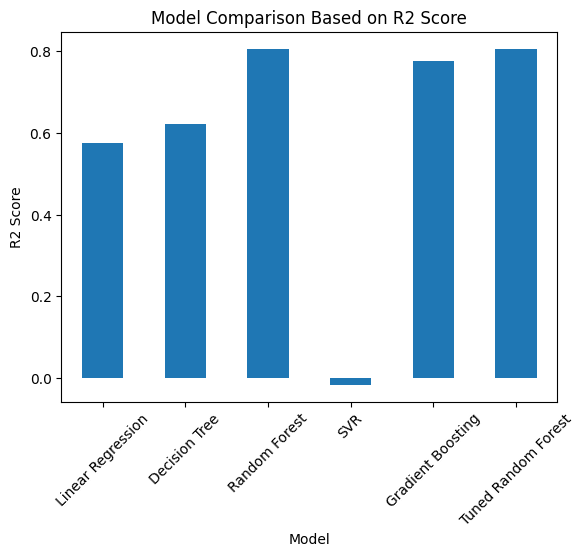

In [ ]:
# Visualize Model Comparison
results_df.set_index("Model")["R2 Score"].plot(kind="bar")
plt.title("Model Comparison Based on R2 Score")
plt.ylabel("R2 Score")
plt.xticks(rotation=45)
plt.show()